In [3]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [6]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

months: 6, 7, 8, 9, 10, 
years: 2010, 2011, 2012, 2013, 2018, 2019, 2020, 2021, 


In [7]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2022_Cases_Dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 11, 
years: 2022, 


In [8]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'
path2 = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2022.csv'

In [9]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.390000,11.935000,6.845,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,0.015560,0.015560,0.015560,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,5,0,0
1,21.94079,40.97703,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.48134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.657273,11.324545,5.990,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,0.248551,0.248551,0.248551,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,0,0
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,7,0,0
3,23.98253,40.91510,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.42581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.742500,13.120000,8.365,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,0.055994,0.055994,0.055994,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,20,0,0
4,23.69108,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,747.0,16994.0,24.5,46.91682,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.0,0.0,0.0,0.0,11.447500,15.240000,7.655,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,1.750566,1.750566,1.750566,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,4,0,0


In [10]:
#Check months

dataset = dataset.query('month >= 6 & month <= 11')
dataset.reset_index(inplace=True, drop=True)

In [11]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-06-01,κεντρικης μακεδονιας,αλεξανδρειας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,478.8,38293.0,86.8,46.44911,0.237090,-0.048711,-0.317377,0.048711,0.233606,-0.039714,-0.304677,0.039714,0.064241,0.055555,0.021262,0.055555,27.490000,38.045000,16.935000,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,27.661434,69.883681,634.525996,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,5,10,0
1,21.94079,40.97703,2010-06-01,κεντρικης μακεδονιας,αλμωπιας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,985.8,24924.0,28.0,46.48134,0.610494,0.297777,-0.269769,-0.297777,0.589813,0.268988,-0.282681,-0.268988,0.054153,0.046797,0.051947,0.046797,19.087273,24.759091,13.415455,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,19.182475,53.285836,708.081877,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,2,0
2,22.89198,40.65603,2010-06-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,0.158598,-0.002042,-0.195420,0.002042,0.161290,-0.000149,-0.195554,0.000149,0.079131,0.039658,0.030081,0.039658,26.500000,35.950000,17.050000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,60.840037,99.001511,625.519261,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,7,14,0
3,23.98253,40.91510,2010-06-01,κεντρικης μακεδονιας,αμφιπολης,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,411.8,7169.0,22.3,47.42581,0.600695,0.348246,-0.219345,-0.348246,0.564287,0.283836,-0.257383,-0.283836,0.049732,0.050856,0.027357,0.050856,24.495000,30.690000,18.300000,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,29.119374,48.335329,661.806941,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,20,40,0
4,23.69108,40.49593,2010-06-01,κεντρικης μακεδονιας,αριστοτελη,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,747.0,16994.0,24.5,46.91682,0.517065,0.247244,-0.249138,-0.247244,0.548352,0.286086,-0.228926,-0.286086,0.042899,0.042628,0.027381,0.042628,19.367500,24.000000,14.735000,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,27.828753,56.447650,608.274993,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,4,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5763,22.14670,40.82294,2021-08-16,κεντρικης μακεδονιας,σκυδρας,16,8,33,2021,-0.101168,-0.994869,-8.660254e-01,-0.5,-0.696551,-0.717507,239.5,18080.0,84.3,46.44339,0.445122,0.014416,-0.427180,-0.014416,0.443690,0.017735,-0.421358,-0.017735,0.118285,0.115395,0.067481,0.115395,30.280000,37.640000,22.920000,8.027348,-1.694000,16.188258,3.720184,18.65

In [12]:
dataset2 = read_data(path2, exclude_years = years_to_remove)
dataset2.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2022-01-01,κεντρικης μακεδονιας,αλεξανδρειας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.450000,8.126419,-1.340303,16.216012,1.011667,18.020179,1.565813,32.641755,8.896456,0.113685,0.113685,0.113685,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,26,0,0
1,21.94079,40.97703,2022-01-01,κεντρικης μακεδονιας,αλμωπιας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,985.8,24924.0,28.0,46.48134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.810778,12.236000,7.385556,5.156188,-0.429920,9.002046,1.203846,8.268402,0.655058,20.890796,6.749332,2.557299,2.557299,2.557299,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,0,0
2,22.89198,40.65603,2022-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.770000,8.206667,1.223333,14.106000,3.702000,17.271538,2.883846,26.801250,9.896667,0.000000,0.000000,0.000000,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,26,0,0
3,23.98253,40.91510,2022-01-01,κεντρικης μακεδονιας,αμφιπολης,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,411.8,7169.0,22.3,47.42581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.935000,5.506350,-0.849211,10.168715,1.184231,13.528745,0.333718,22.552471,8.162000,0.417504,0.417504,0.417504,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,79,20,79.0,20,79,9,9,4,1,1,2,0,26,0,0
4,23.69108,40.49593,2022-01-01,κεντρικης μακεδονιας,αριστοτελη,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,747.0,16994.0,24.5,46.91682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.014583,9.186667,6.842500,5.626176,0.027273,8.827055,1.857362,12.089767,0.979534,20.756913,8.392523,0.000000,0.000000,0.000000,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,0,0


In [13]:
#Check months

dataset2 = dataset2.query('month >= 6 & month <= 11')
dataset2.reset_index(inplace=True, drop=True)

In [14]:
dataset2

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2022-06-01,κεντρικης μακεδονιας,αλεξανδρειας,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,478.8,38293.0,86.8,46.44911,0.203561,0.003898,-0.207792,-0.003898,0.192471,-0.005826,-0.202880,0.005826,0.044951,0.038408,0.034214,0.038408,29.272500,38.310000,20.235000,8.126419,-1.340303,16.216012,1.011667,18.020179,1.565813,32.641755,8.896456,7.430859,60.492267,339.782435,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.000000,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,26,52,0
1,21.94079,40.97703,2022-06-01,κεντρικης μακεδονιας,αλμωπιας,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,985.8,24924.0,28.0,46.48134,0.619276,0.251041,-0.511561,-0.251041,0.621279,0.252002,-0.514743,-0.252002,0.051984,0.044962,0.040620,0.044962,20.111818,23.310000,16.913636,5.156188,-0.429920,9.002046,1.203846,8.268402,0.655058,20.890796,6.749332,32.516852,41.760239,468.251021,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.000000,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,2,0
2,22.89198,40.65603,2022-06-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,0.098917,-0.022971,-0.126924,0.022971,0.130002,-0.019382,-0.158113,0.019382,0.048773,0.022557,0.040199,0.022557,29.500000,36.550000,22.450000,8.206667,1.223333,14.106000,3.702000,17.271538,2.883846,26.801250,9.896667,2.566023,60.273106,469.045192,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.000000,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,26,52,0
3,23.98253,40.91510,2022-06-01,κεντρικης μακεδονιας,αμφιπολης,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,411.8,7169.0,22.3,47.42581,0.476810,0.181223,-0.427585,-0.181223,0.475048,0.176300,-0.423468,-0.176300,0.061094,0.069950,0.033972,0.069950,23.105000,28.415000,17.795000,5.506350,-0.849211,10.168715,1.184231,13.528745,0.333718,22.552471,8.162000,135.776673,137.128588,490.154914,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.000000,116.778232,22,79,20,79.0,20,79,9,9,4,1,1,2,0,26,52,0
4,23.69108,40.49593,2022-06-01,κεντρικης μακεδονιας,αριστοτελη,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,747.0,16994.0,24.5,46.91682,0.692618,0.339332,-0.580010,-0.339332,0.681440,0.327785,-0.573466,-0.327785,0.040490,0.045362,0.027481,0.045362,21.703750,26.225000,17.182500,5.626176,0.027273,8.827055,1.857362,12.089767,0.979534,20.756913,8.392523,7.843521,9.150648,585.233898,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.000000,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,22.48398,40.64468,2022-08-16,κεντρικης μακεδονιας,αλεξανδρειας,16,8,33,2022,-0.101168,-0.994869,-8.660254e-01,-0.5,-0.696551,-0.717507,478.8,38293.0,86.8,46.44911,0.694571,0.353325,-0.589602,-0.353325,0.685882,0.343081,-0.584848,-0.343081,0.043877,0.051278,0.035686,0.051278,25.332500,31.340000,19.325000,8.126419,-1

In [15]:
dataset['lau1'].unique().shape

(38,)

In [16]:
dataset2['lau1'].unique().shape

(38,)

In [17]:
dataset = pd.concat([dataset, dataset2], axis=0)

In [18]:
dataset.reset_index(drop=True, inplace=True)

In [19]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-06-01,κεντρικης μακεδονιας,αλεξανδρειας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,478.8,38293.0,86.8,46.44911,0.237090,-0.048711,-0.317377,0.048711,0.233606,-0.039714,-0.304677,0.039714,0.064241,0.055555,0.021262,0.055555,27.490000,38.045000,16.935000,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,27.661434,69.883681,634.525996,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.000000,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,5,10,0
1,21.94079,40.97703,2010-06-01,κεντρικης μακεδονιας,αλμωπιας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,985.8,24924.0,28.0,46.48134,0.610494,0.297777,-0.269769,-0.297777,0.589813,0.268988,-0.282681,-0.268988,0.054153,0.046797,0.051947,0.046797,19.087273,24.759091,13.415455,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,19.182475,53.285836,708.081877,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.000000,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,2,0
2,22.89198,40.65603,2010-06-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,0.158598,-0.002042,-0.195420,0.002042,0.161290,-0.000149,-0.195554,0.000149,0.079131,0.039658,0.030081,0.039658,26.500000,35.950000,17.050000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,60.840037,99.001511,625.519261,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.000000,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,7,14,0
3,23.98253,40.91510,2010-06-01,κεντρικης μακεδονιας,αμφιπολης,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,411.8,7169.0,22.3,47.42581,0.600695,0.348246,-0.219345,-0.348246,0.564287,0.283836,-0.257383,-0.283836,0.049732,0.050856,0.027357,0.050856,24.495000,30.690000,18.300000,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,29.119374,48.335329,661.806941,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.000000,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,20,40,0
4,23.69108,40.49593,2010-06-01,κεντρικης μακεδονιας,αριστοτελη,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,747.0,16994.0,24.5,46.91682,0.517065,0.247244,-0.249138,-0.247244,0.548352,0.286086,-0.228926,-0.286086,0.042899,0.042628,0.027381,0.042628,19.367500,24.000000,14.735000,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,27.828753,56.447650,608.274993,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.000000,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,4,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6261,22.48398,40.64468,2022-08-16,κεντρικης μακεδονιας,αλεξανδρειας,16,8,33,2022,-0.101168,-0.994869,-8.660254e-01,-0.5,-0.696551,-0.717507,478.8,38293.0,86.8,46.44911,0.694571,0.353325,-0.589602,-0.353325,0.685882,0.343081,-0.584848,-0.343081,0.043877,0.051278,0.035686,0.051278,25.332500,31.340000,19.325000,8.126419,-1.3

In [20]:
print(f'Number of LAU1 Units in {NUTS2}: {len(dataset.lau1.unique())}')

Number of LAU1 Units in CMacedonia: 38


In [21]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,367,250,617,9.85%
1,2011,432,31,463,7.39%
2,2012,437,20,457,7.29%
3,2013,439,21,460,7.34%
4,2014,456,0,456,7.28%
5,2015,456,0,456,7.28%
6,2016,456,0,456,7.28%
7,2017,456,0,456,7.28%
8,2018,387,117,504,8.04%
9,2019,420,53,473,7.55%


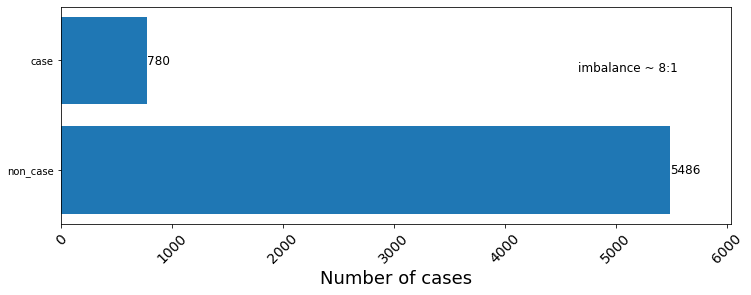

In [22]:
plot_imbalance(dataset)

In [23]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [24]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:4 || ##
Year: 2011 || w0:1, w1:3 || ##
Year: 2012 || w0:1, w1:3 || ##
Year: 2013 || w0:1, w1:3 || ##
Year: 2014 || w0:1, w1:3 || ##
Year: 2015 || w0:1, w1:3 || ##
Year: 2016 || w0:1, w1:3 || ##
Year: 2017 || w0:1, w1:3 || ##
Year: 2018 || w0:1, w1:3 || ##
Year: 2019 || w0:1, w1:3 || ##
Year: 2020 || w0:1, w1:3 || ##
Year: 2021 || w0:1, w1:3 || ##
Year: 2022 || w0:1, w1:4 || ##


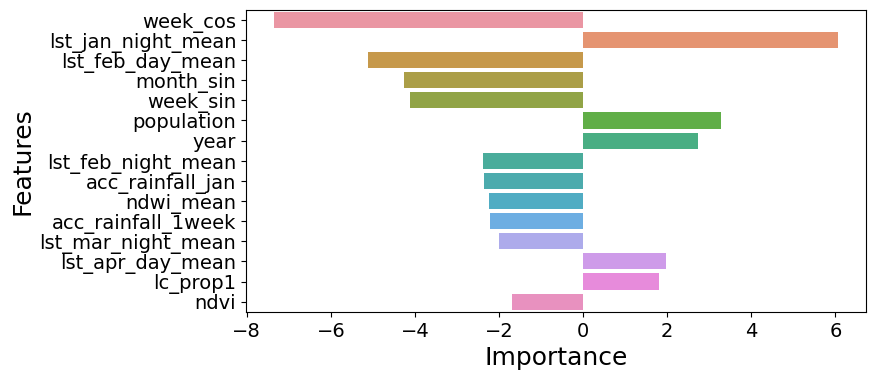

In [25]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

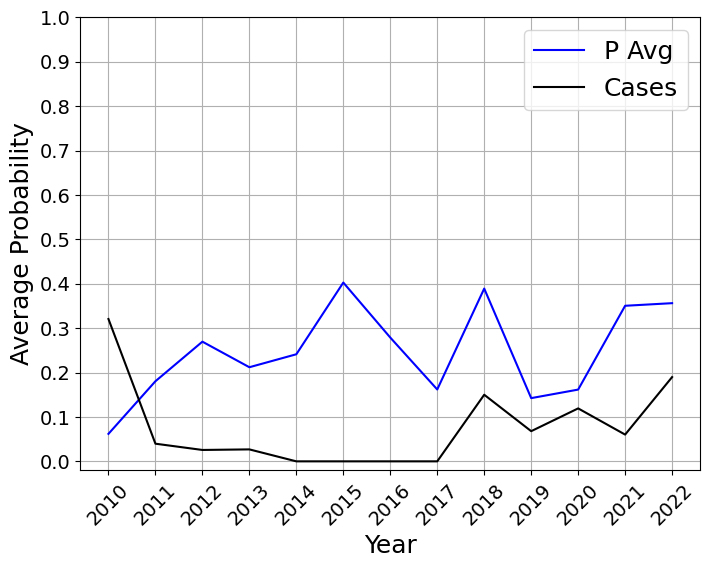

In [26]:
plot_trend_curve(results_test, list(dsc['case']))

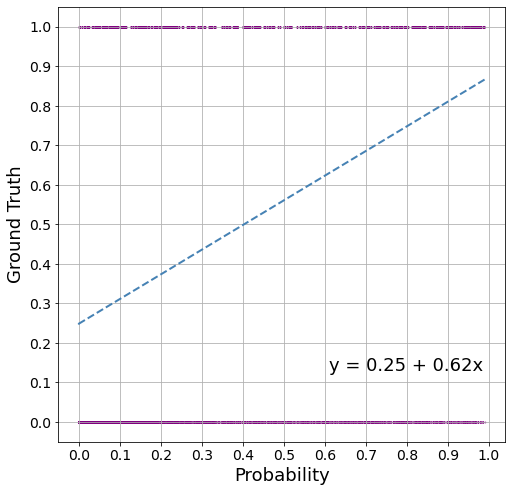

In [27]:
plot_probability_curve(results_test)

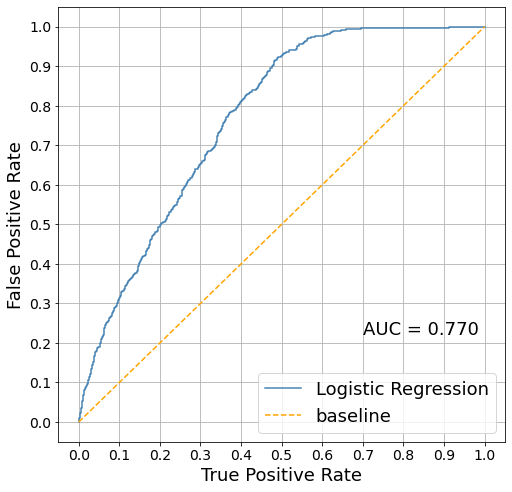

In [28]:
plot_roc_curve(results_test)

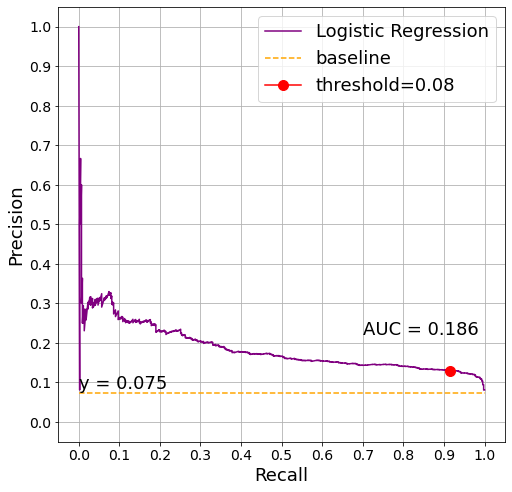

In [29]:
plot_pr_curve(results_test, plot_fbeta=True)

In [30]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 4, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 36.45%
Weighted Average: 43.20%

Random Average: 21.92%
Random Weighted Average: 28.97%


In [31]:
operational

,Prediction Date,Infected,Discovered,Random Discovered,Out of,Percentage,percentage,Random Percentage,random percentage
0,01/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
1,16/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
2,01/07/2010,1,0,0.07,1,0.00 %,0.00,7.00 %,0.0700
3,16/07/2010,12,3,1.26,4,75.00 %,0.75,31.50 %,0.3150
4,01/08/2010,23,4,2.37,4,100.00 %,1.00,59.25 %,0.5925
...,...,...,...,...,...,...,...,...,...
151,16/09/2022,22,3,2.33,4,75.00 %,0.75,58.25 %,0.5825
152,01/10/2022,11,2,1.16,4,50.00 %,0.50,29.00 %,0.2900
153,16/10/2022,2,0,0.13,2,0.00 %,0.00,6.50 %,0.0650
154,01/11/2022,0,0,0.00,0,NaN,NaN,NaN,NaN


In [32]:
cumulative

,Year,Infected,Discovered,Random Discovered,Out Of,Percentage,percentage,Random Percentage,random percentage
0,2010,89,16,9.22,21,76.19 %,0.7619,43.90 %,0.4390
1,2011,24,7,2.58,17,41.18 %,0.4118,15.18 %,0.1518
2,2012,19,3,2.11,19,15.79 %,0.1579,11.11 %,0.1111
3,2013,17,2,1.76,17,11.76 %,0.1176,10.35 %,0.1035
4,2014,0,0,0.00,0,nan %,NaN,nan %,NaN
5,2015,0,0,0.00,0,nan %,NaN,nan %,NaN
6,2016,0,0,0.00,0,nan %,NaN,nan %,NaN
7,2017,0,0,0.00,0,nan %,NaN,nan %,NaN
8,2018,69,10,7.20,29,34.48 %,0.3448,24.83 %,0.2483
9,2019,36,5,3.66,20,25.00 %,0.2500,18.30 %,0.1830


In [33]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.1, beta = 4)

In [34]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,89.0,0.1952,0.7836,0.6517,0.6517,0.6517,0.4247
1,2011,24.0,0.4298,0.7789,0.1173,0.9583,0.6741,0.2630
2,2012,19.0,0.5175,0.7243,0.0763,0.9474,0.5667,0.5094
3,2013,17.0,0.4693,0.7451,0.0748,0.9412,0.5597,0.3226
4,2014,0.0,0.5088,0.4912,0.0000,0.0000,0.0000,0.3866
5,2015,0.0,0.6250,0.3750,0.0000,0.0000,0.0000,0.8698
6,2016,0.0,0.5526,0.4474,0.0000,0.0000,0.0000,0.4655
7,2017,0.0,0.4057,0.5943,0.0000,0.0000,0.0000,0.2374
8,2018,69.0,0.6250,0.7124,0.2386,0.9855,0.8323,0.6056
9,2019,36.0,0.3684,0.7524,0.1786,0.8333,0.6855,0.2925


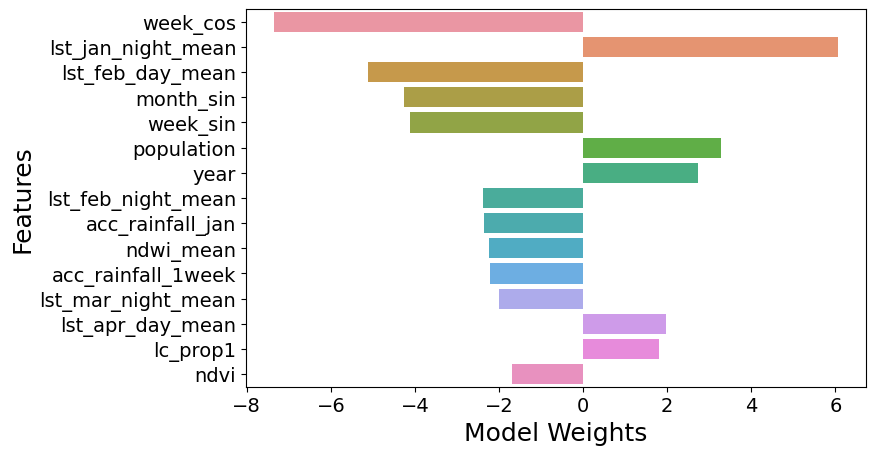

In [35]:
plot_feature_importance(coefficients, feature_names,  x_label = 'Model Weights', top = 15, figure_size = (8, 5))

In [42]:
results_test[results_test['year'] == 2021].head(30)

,x,y,municipality,day,month,year,case,probability
0,22.95369,40.62334,θεσσαλονικης,16,8,2021,0,0.989443
1,22.48398,40.64468,αλεξανδρειας,16,8,2021,1,0.988773
2,22.48398,40.64468,αλεξανδρειας,1,8,2021,1,0.988579
4,22.48398,40.64468,αλεξανδρειας,1,9,2021,1,0.986129
10,22.48398,40.64468,αλεξανδρειας,16,9,2021,1,0.981943
13,22.95369,40.62334,θεσσαλονικης,1,8,2021,0,0.979550
18,22.95369,40.62334,θεσσαλονικης,1,9,2021,0,0.977381
35,22.71688,40.59973,δελτα,1,8,2021,1,0.968789
41,22.71688,40.59973,δελτα,16,8,2021,0,0.967252
44,22.15177,40.44520,βεροιας,16,8,2021,1,0.966331


In [43]:
################# temp

In [86]:
a = results_test[(results_test['year'] == 2021) & (results_test['month'] == 7) & (results_test['day'] == 1)].sort_values('municipality')

In [87]:
a.reset_index(drop=True, inplace=True)

In [88]:
a

,x,y,municipality,day,month,year,case,probability
0,22.48398,40.64468,αλεξανδρειας,1,7,2021,0,0.881514
1,21.94079,40.97703,αλμωπιας,1,7,2021,0,0.082990
2,22.89198,40.65603,αμπελοκηπων μενεμενης,1,7,2021,0,0.181613
3,23.98253,40.91510,αμφιπολης,1,7,2021,0,0.097661
4,23.69108,40.49593,αριστοτελη,1,7,2021,0,0.059947
5,22.15177,40.44520,βεροιας,1,7,2021,0,0.694908
6,23.55924,40.87800,βισαλτιας,1,7,2021,0,0.515896
7,23.46484,40.67596,βολβης,1,7,2021,0,0.291722
8,22.71688,40.59973,δελτα,1,7,2021,0,0.724273
9,22.47713,40.13156,διου ολυμπου,1,7,2021,0,0.195904


In [89]:
import geopandas as gpd
from preprocessing_utils import process_greek

In [90]:
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"

In [91]:
enc = 'utf-8'

In [92]:
greece_gdf = gpd.read_file(f"{folder_path}/elladitsa.shp",  encoding=enc)

In [93]:
greece_gdf

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."
...,...,...,...
321,Ψαρών,9267,"MULTIPOLYGON (((25.48981 38.53091, 25.48952 38..."
322,Ωραιοκάστρου,9039,"MULTIPOLYGON (((22.80634 40.70464, 22.81176 40..."
323,Ωρωπού,9227,"POLYGON ((23.73102 38.33503, 23.73114 38.33480..."
324,Κιμώλου,9286,"MULTIPOLYGON (((24.64532 36.74152, 24.64509 36..."


In [94]:
greece_gdf.rename(columns={"NAME": "lau1"}, inplace = True)
process_greek(greece_gdf, 'lau1')

In [95]:
greece_gdf.drop(columns=['KWD_YPES'], inplace = True)

In [96]:
greece_gdf

,lau1,geometry
0,αμυνταιου,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,αθως,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,ακτιου βονιτσας,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,ανδρου,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,αργους μυκηνων,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."
...,...,...
321,ψαρων,"MULTIPOLYGON (((25.48981 38.53091, 25.48952 38..."
322,ωραιοκαστρου,"MULTIPOLYGON (((22.80634 40.70464, 22.81176 40..."
323,ωρωπου,"POLYGON ((23.73102 38.33503, 23.73114 38.33480..."
324,κιμωλου,"MULTIPOLYGON (((24.64532 36.74152, 24.64509 36..."


In [97]:
a.rename(columns={"municipality": "lau1"}, inplace = True)

In [98]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

names_from_shape = greece_gdf["lau1"].drop_duplicates().sort_values().tolist()
names_from_a = a["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_a:
    if element not in names_from_shape:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [99]:
merged = pd.merge(greece_gdf,a , how='inner', on=['lau1'] )

In [100]:
merged

,lau1,geometry,x,y,day,month,year,case,probability
0,εδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344...",21.98847,40.78394,1,7,2021,0,0.239015
1,αλεξανδρειας,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40...",22.48398,40.64468,1,7,2021,0,0.881514
2,αλμωπιας,"POLYGON ((22.22498 41.16444, 22.22529 41.16444...",21.94079,40.97703,1,7,2021,0,0.082990
3,αμπελοκηπων μενεμενης,"POLYGON ((22.87764 40.66601, 22.87775 40.66573...",22.89198,40.65603,1,7,2021,0,0.181613
4,αμφιπολης,"POLYGON ((24.04143 41.04942, 24.04322 41.04930...",23.98253,40.91510,1,7,2021,0,0.097661
5,αριστοτελη,"MULTIPOLYGON (((23.95413 40.30814, 23.95414 40...",23.69108,40.49593,1,7,2021,0,0.059947
6,βεροιας,"POLYGON ((22.27790 40.64388, 22.27864 40.64335...",22.15177,40.44520,1,7,2021,0,0.694908
7,βισαλτιας,"POLYGON ((23.35679 41.01548, 23.35736 41.01548...",23.55924,40.87800,1,7,2021,0,0.515896
8,βολβης,"POLYGON ((23.49241 40.84242, 23.49332 40.84236...",23.46484,40.67596,1,7,2021,0,0.291722
9,δελτα,"MULTIPOLYGON (((22.74653 40.51249, 22.74682 40...",22.71688,40.59973,1,7,2021,0,0.724273


In [101]:
type(merged)

geopandas.geodataframe.GeoDataFrame

In [102]:
merged.to_file('temp.shp')

In [85]:
type(greece_gdf)

geopandas.geodataframe.GeoDataFrame